<a href="https://colab.research.google.com/github/GEAR-company-offical/wine-classification-knn/blob/main/wine_classification_knn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Классификация сортов вина методом kNN

**Автор:** Иван Козин  
**Стек:** Python, NumPy, Pandas, Matplotlib, Scikit-learn

Будем работать со встроенным в `sklearn` набором данных `wine`, содержащим информацию о характеристиках трёх сортов вина. Описание набора можно найти [здесь](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html#sklearn.datasets.load_wine) и [здесь](https://rdrr.io/cran/rattle.data/man/wine.html).

Загрузим набор данных и сохраним информацию о признаках в переменную `X`, а о зависимой переменной – в переменную `y`.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from sklearn.datasets import load_wine

data = load_wine()
X = pd.DataFrame(data['data'], columns = data['feature_names'])
y = data['target']

## 1. Загрузка данных и первичный анализ (EDA)

Выведите первые 5 строк таблицы `X`.

Выведите `y`.

Выведите размер таблицы.

Проверьте, есть ли в наборе данных пропущенные значения? Если да, то удалите их.

Проверьте, какие типы переменных содержат данные?

Есть ли в наборе данных категориальные признаки? Если да, то закодируйте их при помощи OneHot-кодирования.

Какие значения принимает переменная `y`? Как распределены эти значения (если возможно, то посчитайте количество для каждого значения). Проверьте, содержит ли переменная `y` пропуски.

Постройте гистограмму распределения переменной `y`. График должен содержать название, подпишите оси. Для построения вы можете использовать функцию `hist` библиотеки `matplotlib`.

Какой тип задачи машинного обучения можно решать с такими данными?

In [ ]:
# Первые 5 строк таблицы X
X.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [ ]:
# Значения зависимой переменной y
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2])

In [ ]:
# Размер таблицы X (строки, столбцы)
print('Размер X:', X.shape)
print('Размер y:', y.shape)

Размер X: (178, 13)
Размер y: (178,)


In [ ]:
# Пропущенные значения в X
print('Всего пропусков в X:', X.isna().sum().sum())
X.isna().sum()

Всего пропусков в X: 0


,0
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0


In [ ]:
# Типы переменных
X.dtypes

,0
alcohol,float64
malic_acid,float64
ash,float64
alcalinity_of_ash,float64
magnesium,float64
total_phenols,float64
flavanoids,float64
nonflavanoid_phenols,float64
proanthocyanins,float64
color_intensity,float64


In [ ]:
# Категориальные признаки (object / category / bool)
cat_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns
print('Категориальные признаки:', list(cat_cols))
print('Уникальных значений у каждого признака:')
X.nunique()

Категориальные признаки: []
Уникальных значений у каждого признака:


,0
alcohol,126
malic_acid,133
ash,79
alcalinity_of_ash,63
magnesium,53
total_phenols,97
flavanoids,132
nonflavanoid_phenols,39
proanthocyanins,101
color_intensity,132


In [ ]:
# Значения y и их распределение
values, counts = np.unique(y, return_counts=True)
print('Значения y:', values)
print('Названия классов:', list(data['target_names']))
for v, c in zip(values, counts):
    print(f'class {v} ({data["target_names"][v]}): {c} объектов, {c / len(y):.1%}')
print('Пропусков в y:', pd.isna(y).sum())

Значения y: [0 1 2]
Названия классов: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]
class 0 (class_0): 59 объектов, 33.1%
class 1 (class_1): 71 объектов, 39.9%
class 2 (class_2): 48 объектов, 27.0%
Пропусков в y: 0


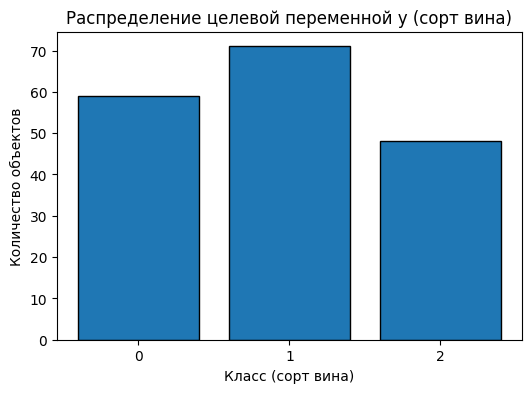

In [ ]:
# Гистограмма распределения y
plt.figure(figsize=(6, 4))
plt.hist(y, bins=[-0.5, 0.5, 1.5, 2.5], rwidth=0.8, edgecolor='black')
plt.xticks([0, 1, 2])
plt.title('Распределение целевой переменной y (сорт вина)')
plt.xlabel('Класс (сорт вина)')
plt.ylabel('Количество объектов')
plt.show()

### Вывод

- Размер таблицы `X`: 178 объектов × 13 признаков; `y` – вектор из 178 значений.
- Пропущенных значений нет ни в `X`, ни в `y`, поэтому удалять нечего.
- Все 13 признаков имеют тип `float64` (вещественные). Категориальных признаков нет, поэтому OneHot-кодирование не требуется.
- Переменная `y` принимает три значения: 0, 1, 2 (три сорта вина) с количеством объектов 59, 71 и 48 соответственно. Классы распределены достаточно равномерно, сильного дисбаланса нет.
- Целевая переменная дискретна (три класса), поэтому с такими данными решается задача **многоклассовой классификации** (обучение с учителем).

Далее будем работать только с двумя признаками: `alcohol` и `magnesium`.

## 2. Разделение на train и test.

Создайте для признаков `alcohol` и `magnesium` отдельный DataFrame `X_a_m`.

Разделите данные (с двумя признаками `alcohol` и `magnesium`) и соответствующие значения `y` на тренировочные и тестовые данные (`X_train`, `X_test`, `y_train`, `y_test`), долю тестовой выборки задайте равной 0.3. Выведите размеры полученных тренировочной и тестовой выборок.

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_a_m = X[['alcohol', 'magnesium']]

RANDOM_STATE = 8  #для воспроизводимости результатов

X_train, X_test, y_train, y_test = train_test_split(
    X_a_m, y, test_size=0.3, random_state=RANDOM_STATE
)

print('Тренировочная выборка:', X_train.shape, y_train.shape)
print('Тестовая выборка:     ', X_test.shape, y_test.shape)

Тренировочная выборка: (124, 2) (124,)
Тестовая выборка:      (54, 2) (54,)


## 3. Обучение kNN без масштабирования

На тренировочной выборке обучите шесть классификаторов kNN, отличающихся только числом соседей. Для первого классификатора число соседей поставьте равным 1, для второго - 3, для третьего – 5, для четвертого – 10, для пятого – 15 и для шестого – 25 (обратите внимание на параметр `n_neighbours` класса `KNeighborsClassifier`). Для обучения используйте евклидово расстояние.

Вычислите долю правильных ответов `accuracy` на тренировочной и тестовой выборках для каждого классификатора. Выведите эту информацию в одном месте (в таблице или в отдельном DataFrame)

Что вы можете сказать о качестве классификации?

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [ ]:
n_neighbors_list = [1, 3, 5, 10, 15, 25]
rows = []

for k in n_neighbors_list:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')  # p=2, евклидово расстояние
    knn.fit(X_train, y_train)
    rows.append({
        'NN': k,
        'Train': accuracy_score(y_train, knn.predict(X_train)),
        'Test': accuracy_score(y_test, knn.predict(X_test)),
    })

res_raw = pd.DataFrame(rows).set_index('NN').round(3)
res_raw

,Train,Test
NN,,
1,0.992,0.593
3,0.782,0.537
5,0.750,0.593
10,0.653,0.593
15,0.605,0.500
25,0.589,0.519


### Вывод
- При `k = 1` точность на обучающей выборке равна 0.992 (каждый объект – собственный ближайший сосед), а на тестовой – только 0.593: классификатор просто запоминает обучающую выборку, то есть **переобучается**.
- С ростом `k` модель становится более гладкой и разрыв между train и test сокращается, но точность на обучающей выборке падает, а на тестовой остаётся невысокой (лучший результат 0.593 при `k = 1`). При больших `k` (15, 25) модель уже начинает недообучаться.
- В целом качество классификации невысокое. Две причины: по двум признакам классы разделяются плохо, а главное – признаки **не масштабированы**. Магнезий имеет разброс порядка 14 единиц, а алкоголь – порядка 0.8, поэтому в евклидовом расстоянии практически полностью доминирует `magnesium`, а `alcohol` почти не влияет на выбор соседей.

## 4. Визуализация распределения признаков

Посмотрим на распределение признаков `alcohol` и `magnesium` в `X_a_m`.

На одной координатной плоскости постройте гистограммы распределения признаков `alcohol` и `magnesium`. Для построения вы можете использовать функцию `hist` библиотеки `matplotlib` или `histplot` бибилиотеки `seaborn`. Дайте графику название, подпишите оси.

Далее на одной координатной плоскости постройте ящичковые диаграммы распределения признаков `alcohol` и `magnesium`. Как вариант, вы можете использовать функцию `boxplot` бибилиотек `matplotlib` или `seaborn`. Дайте графику название, подпишите оси.

Что вы можете сказать о распределении признаков `alcohol` и `magnesium`? Какое представление лучше подчеркивает особенности распределения?

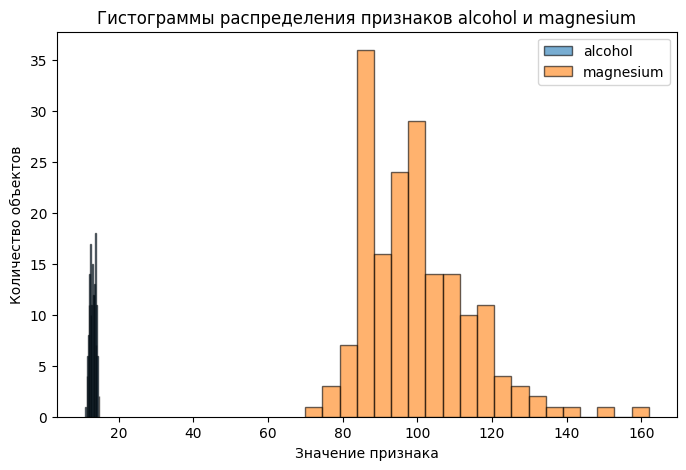

In [ ]:
# Гистограммы на одной координатной плоскости
plt.figure(figsize=(8, 5))
plt.hist(X_a_m['alcohol'], bins=20, alpha=0.6, label='alcohol', edgecolor='black')
plt.hist(X_a_m['magnesium'], bins=20, alpha=0.6, label='magnesium', edgecolor='black')
plt.title('Гистограммы распределения признаков alcohol и magnesium')
plt.xlabel('Значение признака')
plt.ylabel('Количество объектов')
plt.legend()
plt.show()

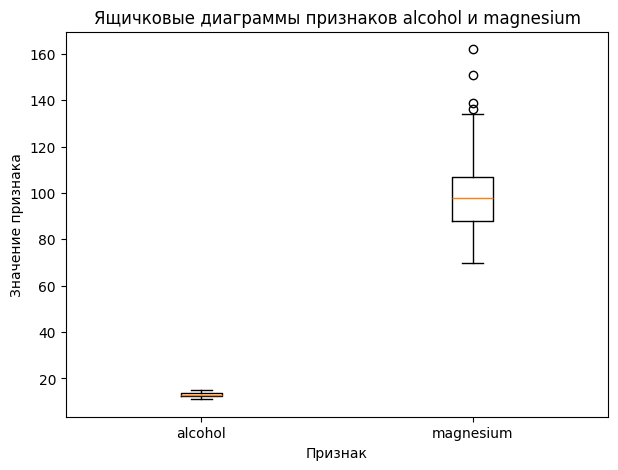

In [ ]:
# Ящичковые диаграммы на одной координатной плоскости
plt.figure(figsize=(7, 5))
plt.boxplot([X_a_m['alcohol'], X_a_m['magnesium']])
plt.xticks([1, 2], ['alcohol', 'magnesium'])
plt.title('Ящичковые диаграммы признаков alcohol и magnesium')
plt.xlabel('Признак')
plt.ylabel('Значение признака')
plt.show()

In [ ]:
X_a_m.describe()

,alcohol,magnesium
count,178.000000,178.000000
mean,13.000618,99.741573
std,0.811827,14.282484
min,11.030000,70.000000
25%,12.362500,88.000000
50%,13.050000,98.000000
75%,13.677500,107.000000
max,14.830000,162.000000


### Вывод

- Признаки находятся в **совершенно разных масштабах**: `alcohol` лежит в диапазоне примерно 11–15 (среднее ≈ 13, std ≈ 0.8), `magnesium` – в диапазоне 70–162 (среднее ≈ 100, std ≈ 14). На общей оси `alcohol` сжимается в узкую полосу и его распределение почти не видно.
- `alcohol` распределён примерно симметрично, без выбросов. `magnesium` имеет **правостороннюю асимметрию** (длинный правый «хвост») и содержит выбросы в области больших значений (до 162 при верхней границе «усов» около 135).
- Ящичковая диаграмма лучше подчёркивает особенности распределения: на ней видны медиана, квартили, разброс и выбросы, а также различие масштабов признаков. Гистограмма лучше показывает форму распределения, но на одной оси из-за разных масштабов оба распределения почти не пересекаются и сравнивать их неудобно.
- Различие масштабов объясняет плохое качество kNN в задании 1.3 и мотивирует масштабирование признаков.

## 5. Масштабирование признаков (StandardScaler)

Примените масштабирование признаков к `X_train`, `X_test`, используйте модуль `StandardScaler`. Отмасштабированные данные сохраните в новые переменные: `X_train_scaled`, `X_test_scaled`. К какому типу относятся эти пременные ?


*Напоминание*. **Масштабирование** - нормализация (стандартизация): вычитание среднего из каждого признака и деление на стандартное отклонение (`StandardScaler` в sklearn).
$x_{ij}
    :=
    \frac{x_{ij} - \mu_j}{\sigma_j},
$
где $\mu_j = \frac{1}{\ell} \sum_{i = 1}^{\ell} x_{ij}$,
$\sigma_j = \sqrt { \frac{1}{\ell} \sum_{i = 1}^{\ell} (x_{ij} - \mu_j)^2}$.

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

# параметры (среднее и std) считаем ТОЛЬКО по обучающей выборке
X_train_scaled = scaler.fit_transform(X_train)
# к тестовой выборке применяем уже найденные параметры
X_test_scaled = scaler.transform(X_test)

print('Тип X_train_scaled:', type(X_train_scaled))
print('Тип X_test_scaled: ', type(X_test_scaled))
print('Формы:', X_train_scaled.shape, X_test_scaled.shape)
print('Средние по обучающей выборке (mean_):', scaler.mean_)
print('Стандартные отклонения (scale_):     ', scaler.scale_)

Тип X_train_scaled: <class 'numpy.ndarray'>
Тип X_test_scaled:  <class 'numpy.ndarray'>
Формы: (124, 2) (54, 2)
Средние по обучающей выборке (mean_): [13.06870968 99.20967742]
Стандартные отклонения (scale_):      [ 0.84273649 14.08228938]


### Вывод

 `X_train_scaled` и `X_test_scaled` имеют тип `numpy.ndarray` (двумерные массивы), названия столбцов и индексы `DataFrame` при преобразовании теряются. Среднее и стандартное отклонение вычисляются только по обучающей выборке (`fit_transform`), а к тестовой применяется то же преобразование (`transform`), чтобы избежать утечки информации из теста.

## 6. Визуализация после масштабирования

Теперь визуализируйте распределение признаков `X_train_scaled` и `X_test_scaled` вместе или хотя бы только распределение `X_train_scaled`, используя способы из задания 1.4.

*Примечание.* Предварительно можно создать `DataFrame` из `X_train_scaled` и `X_test_scaled` вместе или только из `X_train_scaled`. Во первом случае перед созданием `DataFrame` сначала можно склеить массивы `X_train_scaled` и `X_test_scaled` по строкам (вертикально).

Как изменилось распределение признаков?

In [ ]:
# Склеиваем отмасштабированные train и test по строкам и создаём DataFrame
X_scaled_all = pd.DataFrame(
    np.vstack([X_train_scaled, X_test_scaled]),
    columns=['alcohol', 'magnesium']
)
X_scaled_all.describe()

,alcohol,magnesium
count,178.000000,178.000000
mean,-0.080798,0.037771
std,0.963322,1.014216
min,-2.419154,-2.074214
25%,-0.837996,-0.796012
50%,-0.022201,-0.085901
75%,0.722397,0.553200
max,2.089966,4.458815


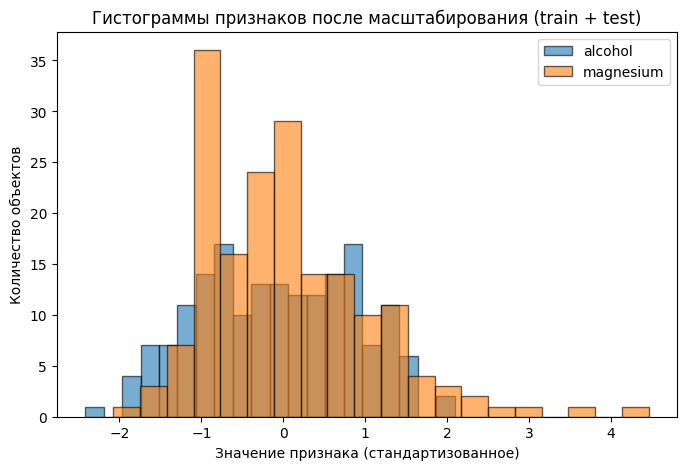

In [ ]:
# Гистограммы на одной координатной плоскости
plt.figure(figsize=(8, 5))
plt.hist(X_scaled_all['alcohol'], bins=20, alpha=0.6, label='alcohol', edgecolor='black')
plt.hist(X_scaled_all['magnesium'], bins=20, alpha=0.6, label='magnesium', edgecolor='black')
plt.title('Гистограммы признаков после масштабирования (train + test)')
plt.xlabel('Значение признака (стандартизованное)')
plt.ylabel('Количество объектов')
plt.legend()
plt.show()

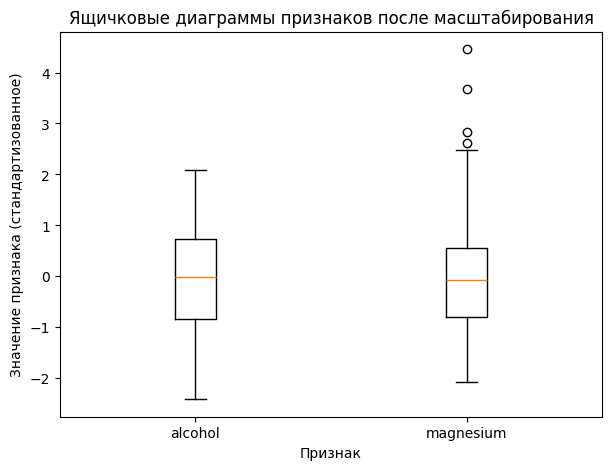

In [ ]:
# Ящичковые диаграммы на одной координатной плоскости
plt.figure(figsize=(7, 5))
plt.boxplot([X_scaled_all['alcohol'], X_scaled_all['magnesium']])
plt.xticks([1, 2], ['alcohol', 'magnesium'])
plt.title('Ящичковые диаграммы признаков после масштабирования')
plt.xlabel('Признак')
plt.ylabel('Значение признака (стандартизованное)')
plt.show()

### Вывод
После стандартизации оба признака приведены к одному масштабу: среднее (по обучающей выборке) равно 0, стандартное отклонение равно 1, значения лежат примерно в диапазоне от −3 до 4. Теперь гистограммы и «ящики» двух признаков находятся на одной оси и хорошо сопоставимы, чего не было до масштабирования. **Форма распределений не изменилась**: стандартизация – линейное преобразование (сдвиг и растяжение), поэтому асимметрия `magnesium` и его выбросы остались, поменялись лишь центр и масштаб. Для kNN это важно: теперь оба признака вносят сопоставимый вклад в евклидово расстояние.

Далее будем работать с масштабированными данными.

## 7. Обучение kNN с масштабированием и сравнение

Данное задание аналогично заданию 1.3 только выполняется на отмасштабированных данных в задании 1.5.

На тренировочной выборке обучите шесть классификаторов kNN, отличающихся только числом соседей. Для первого классификатора число соседей поставьте равным 1, для второго - 3, для третьего – 5, для четвертого – 10, для пятого – 15 и для шестого – 25 (обратите внимание на параметр `n_neighbours` класса `KNeighborsClassifier`). Для обучения используйте евклидово расстояние.

Вычислите долю правильных ответов `accuracy` на тренировочной и тестовой выборках для каждого классификатора. Выведите эту информацию в одном месте (в таблице или в отдельном DataFrame)

Сделайте вывод о качестве классификации.

In [ ]:
rows = []

for k in n_neighbors_list:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(X_train_scaled, y_train)
    rows.append({
        'NN': k,
        'Train': accuracy_score(y_train, knn.predict(X_train_scaled)),
        'Test': accuracy_score(y_test, knn.predict(X_test_scaled)),
    })

res_scaled = pd.DataFrame(rows).set_index('NN').round(3)
res_scaled

,Train,Test
NN,,
1,0.992,0.704
3,0.815,0.630
5,0.766,0.648
10,0.758,0.667
15,0.710,0.648
25,0.734,0.704


In [ ]:
# Для сравнения: точность на тесте без масштабирования и с масштабированием
compare = pd.DataFrame({
    'Test (без масштабирования)': res_raw['Test'],
    'Test (с масштабированием)': res_scaled['Test'],
})
compare

,Test (без масштабирования),Test (с масштабированием)
NN,,
1,0.593,0.704
3,0.537,0.630
5,0.593,0.648
10,0.593,0.667
15,0.500,0.648
25,0.519,0.704


### Вывод

- После масштабирования качество классификации на тестовой выборке в целом **выросло**: лучшая точность на тесте 0.704 (при `k = 1`) против 0.593 без масштабирования. Это ожидаемо: теперь `alcohol` и `magnesium` вносят сопоставимый вклад в евклидово расстояние, а не доминирует один `magnesium`, и оба признака несут информацию о классе.
- При `k = 1` по-прежнему наблюдается переобучение (train = 0.992, test = 0.704). С ростом `k` разрыв между train и test сокращается, и лучшее качество на тесте достигается при умеренных/больших значениях `k` (чем больше соседей, тем более устойчивое и «гладкое» решение).
- Итог: масштабирование признаков – обязательный шаг для метода kNN, так как он основан на расстояниях. Абсолютное качество всё равно ограничено тем, что использованы всего два признака из тринадцати; для улучшения можно добавить остальные признаки и подобрать `k` кросс-валидацией, а не по одному тестовому разбиению.